In [2]:
from transformers import pipeline
from transformers import AutoTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
import numpy as np

## overview

### Automatic Label Generation Using HuggingFace Sentiment Pipeline

In [3]:
sentiment_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [7]:
df = pd.read_csv("news_headings.csv")

In [9]:
data_len = df.shape[0]
for i in range(data_len):
    data = df["news"][i]
    output = sentiment_pipeline(data)
    df.loc[i,"labels"] = output[0]["label"]
    df.loc[i,"scores"] = output[0]["score"]


In [10]:
df.shape[0]

5000

In [11]:
df["labels"].value_counts()

labels
NEGATIVE    3319
POSITIVE    1681
Name: count, dtype: int64

In [12]:
df = df.drop("scores",axis=1)

In [13]:
df["labels"] = df["labels"].map({"POSITIVE":1,"NEGATIVE":0})


# dataset

In [14]:
df.head()

,Unnamed: 0,news,labels
0,0,A ‘lifeline’ restored in Rayalaseema: Andhra m...,1
1,1,"Strengthen security, monitoring of LPG supply ...",1
2,2,He killed comrade for wanting to surrender. Mo...,0
3,3,Jharkhand to Greater Noida via Ahmedabad – jou...,1
4,4,West Asia conflict: PM Modi says India has ade...,1


In [15]:
df.isna().sum()

Unnamed: 0    0
news          0
labels        0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

### device

In [38]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
device

device(type='cuda')

## Spliting dataset into train-test

In [39]:
X = df["news"]
y = df["labels"]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [40]:
train_data  = pd.concat([X_train,y_train],axis=1)
test_data  = pd.concat([X_test,y_test],axis=1)

### Handling Class Imbalance by Assigning Higher Weight to the Positive Class

In [41]:
from sklearn.utils.class_weight import compute_class_weight

# Your labels
labels = train_data['labels'].values

# Compute weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Convert to tensor
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)

tensor([0.7533, 1.4870], device='cuda:0')


## Text Tokenization Using BERT Tokenizer

In [42]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

In [43]:
def token(text,label):
    encode = tokenizer(text,padding="max_length",max_length=512,truncation=True,return_tensors="pt")
    return encode["input_ids"],encode["attention_mask"], torch.tensor(label,dtype=torch.float)

In [44]:
train_input_id,train_attention_mask,train_label = token(text=train_data["news"].tolist(),label=train_data["labels"].tolist())
test_input_id,test_attention_mask,test_label = token(text=test_data["news"].tolist(),label=test_data["labels"].tolist())

### Preparing Input Tensors for Training and Testing

In [45]:
train_dataset = torch.utils.data.TensorDataset(train_input_id,train_attention_mask,train_label)
test_dataset = torch.utils.data.TensorDataset(test_input_id,test_attention_mask,test_label)

In [46]:
len(train_dataset)

4000

### Loading Dataset into DataLoader

In [47]:
batch_size = 64 
train_dataloader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_dataloader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

### Loading Pretrained BERT Model for Classification

In [49]:
model = BertForSequenceClassification.from_pretrained("google-bert/bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Model Fine-Tuning

In [51]:
class NewsClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertForSequenceClassification.from_pretrained("google-bert/bert-base-uncased",num_labels=2)
        
        for param in self.bert.bert.parameters():
            param.requires_grad=False # freeze all BERT layers
            
        for param in self.bert.bert.encoder.layer[-1].parameters():
            param.requires_grad = True
    def forward(self,input_ids,attention_mask):
        bert_output = self.bert(input_ids=input_ids,attention_mask=attention_mask)
        
        return bert_output.logits

In [52]:
model = NewsClassifier()
optimizer = optim.Adam(model.parameters(),lr=2e-5)
criterion = nn.CrossEntropyLoss(weight=class_weights)

model = model.to(device)
criterion = criterion.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### model training

In [53]:
epochs = 5

# training loop
for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch,(input_ids,attention_mask,labels) in enumerate(train_dataloader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        
    
        optimizer.zero_grad()
        
        logits = model(input_ids,attention_mask)
       
        labels = labels.long()
        loss = criterion(logits,labels)
        
        loss.backward()
        optimizer.step()

        
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f" Epoch{epoch +1}/{epochs}, Training loss: {avg_train_loss}")

 Epoch1/5, Training loss: 0.63442386615844
 Epoch2/5, Training loss: 0.476132989875854
 Epoch3/5, Training loss: 0.4188390043046739
 Epoch4/5, Training loss: 0.4023606095995222
 Epoch5/5, Training loss: 0.38877228777559975


### Model Evaluation and Performance Metrics on Test Data

In [54]:
# Evaluation
model.eval()

all_prediction = []
all_labels = []

total_val_loss= 0 
correct_predictions = 0
with torch.no_grad():
    for input_ids,attention_mask,labels in test_dataloader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        labels = labels.long()

        logits = model(input_ids,attention_mask)
        loss = criterion(logits,labels)
        total_val_loss += loss.item()

        pred = torch.argmax(logits,dim=1)
        correct_predictions += torch.sum(pred == labels)

        all_prediction.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_val_loss = total_val_loss / len(test_dataloader)
val_accuracy = correct_predictions.double() / len(test_dataloader.dataset)

print(f"validation loss:{avg_val_loss}, validation_accuracy:{val_accuracy:0.4f}")
        

validation loss:0.4094410724937916, validation_accuracy:0.8320


model accuracy is 80-84%

#### Classification_report

In [74]:
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
report = classification_report(all_labels,all_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       664
           1       0.72      0.82      0.77       336

    accuracy                           0.83      1000
   macro avg       0.81      0.83      0.82      1000
weighted avg       0.84      0.83      0.83      1000



#### Confusion_matrix

In [57]:
cm = confusion_matrix(all_labels,all_prediction)
print(cm)

[[556 108]
 [ 60 276]]


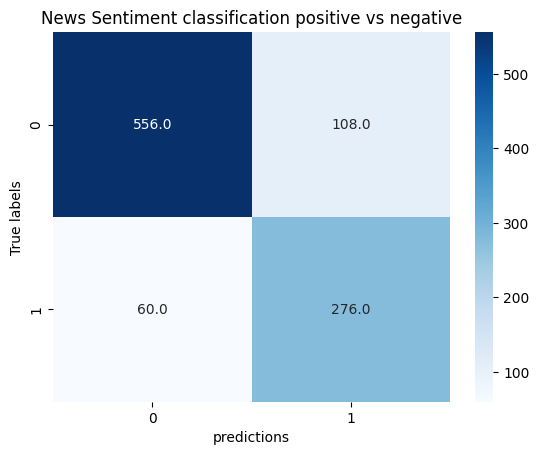

In [78]:
sns.heatmap(cm,cmap="Blues",annot=True,fmt="0.1f")
plt.title("News Sentiment classification positive vs negative")
plt.xlabel("predictions")
plt.ylabel("True labels")
plt.show()

### exporting the model 

In [28]:
# torch.save(model.state_dict(),"balanced_news_model.pth")